In [14]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [15]:
def create_melspectrogram(df, segmented_dir, all_categories, n_mels=128):
    segmented_dir = Path(segmented_dir)
    melspectrogram_list = []
    labels = []

    for index, f in tqdm(df.iterrows()):
        for file in segmented_dir.glob(f'{Path(f.fname).stem}_*.wav'):
            y, sr = librosa.load(file, sr=None)
            melspectrogram = librosa.feature.melspectrogram(y=y, 
                                                      sr=sr, 
                                                      n_mels=n_mels, 
                                                      fmax=sr/2)
            melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
            melspectrogram_list.append(melspectrogram_db)
            labels.append(f.label)
            
    X = np.array(melspectrogram_list)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    label_encoder.fit(all_categories)
    y = label_encoder.transform(labels)

    return X, y

Load train/test DataFrame

In [16]:
train_csv_path = 'kaggle_meta/train_post_competition.csv'
train_df = pd.read_csv(train_csv_path)

In [17]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]

In [18]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('kaggle_data', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

Import data for model

In [19]:
X, y = create_melspectrogram(train_df, 'kaggle_segmented', musical_instruments)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

1847it [00:43, 42.72it/s]


Plot mel spectrogram

In [20]:
def plot_melspectrogram(X, i=0, save_path=None):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

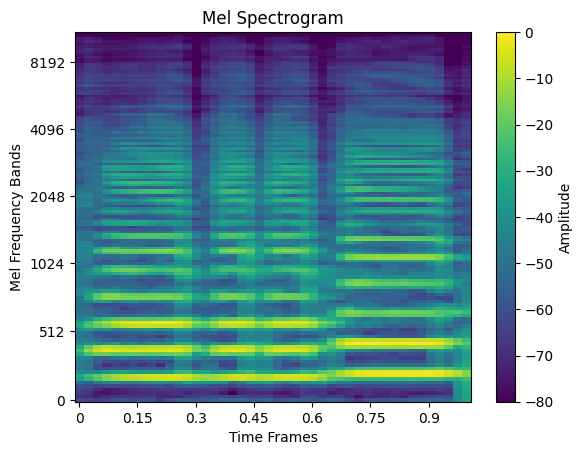

In [21]:
plot_melspectrogram(X, 0, 'kaggle_melspectrogram.png')

CNN model

In [22]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2], 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

Train CNN

In [23]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

with open('kaggle_cnn_melspectrogram_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Epoch 1/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.2118 - loss: 2.3877 - val_accuracy: 0.2504 - val_loss: 2.3781
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.3748 - loss: 1.8387 - val_accuracy: 0.3677 - val_loss: 2.0291
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.4594 - loss: 1.5178 - val_accuracy: 0.4126 - val_loss: 1.5875
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.5182 - loss: 1.2967 - val_accuracy: 0.4509 - val_loss: 1.5954
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.5783 - loss: 1.1286 - val_accuracy: 0.4659 - val_loss: 1.5752
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.6330 - loss: 0.9683 - val_accuracy: 0.2820 - val_loss: 2.7746
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.6639 - loss: 0.8546 - val_accuracy: 0.5499 - val_loss: 1.3988
Epoch 8/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.6845 - loss: 0

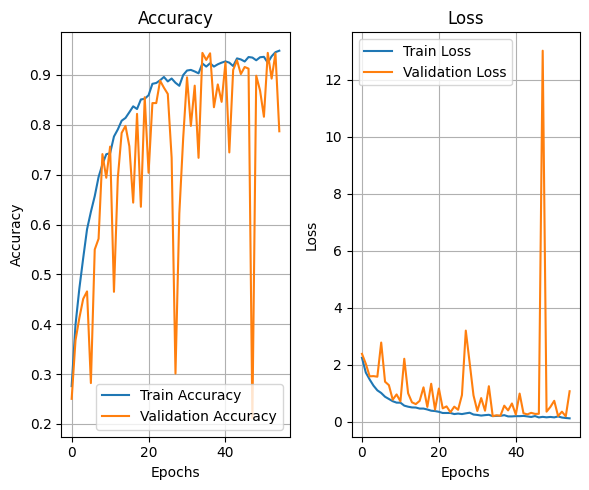

In [24]:
with open('kaggle_cnn_melspectrogram_history.pkl', 'rb') as f:
    history = pickle.load(f)
    
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig('kaggle_cnn_melspectrogram_training_curves.png')
plt.show()

Evaluate CNN

In [25]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = [musical_instruments[i] for i in y_pred]
y_test_labels = [musical_instruments[i] for i in y_test]

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

output_file = 'kaggle_cnn_melspectrogram_evaluation.txt'

with open(output_file, 'w') as file:
    file.write(f'Accuracy: {accuracy}\n')
    file.write('\nClassification Report:\n')
    file.write(class_report)

# best .94

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Accuracy: 0.9221038615179761

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.97      0.90      0.93        98
       Bass_drum       0.75      1.00      0.86        15
           Cello       0.87      0.95      0.91        21
        Clarinet       0.77      0.89      0.82        37
         Cowbell       0.83      0.95      0.89        63
     Double_bass       0.96      0.99      0.97        91
  Electric_piano       0.99      0.86      0.92       322
           Flute       0.88      0.99      0.93       167
    Glockenspiel       0.94      0.93      0.94       151
       Harmonica       1.00      0.93      0.96        28
          Hi-hat       0.86      0.94      0.90        71
            Oboe       0.99      0.88      0.93        95
       Saxophone       0.75      0.94      0.83        16
      Tambourine       0.92      1.00      0.96        23
         Trumpet       0.83      0.

Save CNN

In [26]:
# cnn.save('cnn_melspectrogram_model.h5')